# Chapter 58 — Linear Functions

> **Prerequisites:** ch051–057 (Function foundations and visualization)
>
> **You will learn:**
> - Define and graph linear functions f(x) = mx + b
> - Interpret slope as rate of change and intercept as starting value
> - Fit a line through two points and through noisy data
> - Understand linearity in higher dimensions as a preview of linear algebra
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

A **linear function** is the simplest non-trivial function: f(x) = mx + b. It maps equal changes in input to equal changes in output — the slope m is constant everywhere.

Linear functions are the foundation of almost everything in quantitative analysis:
- Linear regression fits a line to data
- Neural network layers compute linear transformations (then apply an activation)
- Gradient descent step: `x → x - α * gradient` is a linear update
- Euler's method for ODEs is a sequence of linear steps

**Misconception:** 'Linear' sometimes means 'straight line' informally but has a precise meaning: f(αx + βy) = αf(x) + βf(y). The function f(x) = mx + b is *affine*, not strictly linear (unless b=0). This distinction matters in linear algebra.

---

## 2. Intuition & Mental Models

**Physical analogy:** Speed. If you drive at constant speed m km/h, after t hours you are at distance f(t) = mt + b (starting at b). Equal time intervals → equal distance increments. That constancy is linearity.

**Computational analogy:** Scaling a NumPy array by a constant: `x * m + b`. Same operation, applied element-wise. The slope m stretches or compresses values; the intercept b shifts them.

Recall from ch041 (Exponents and Powers): we noted that linear growth (constant addition) is the slowest growth pattern. Now we formalize what that means.

---

## 3. Visualization

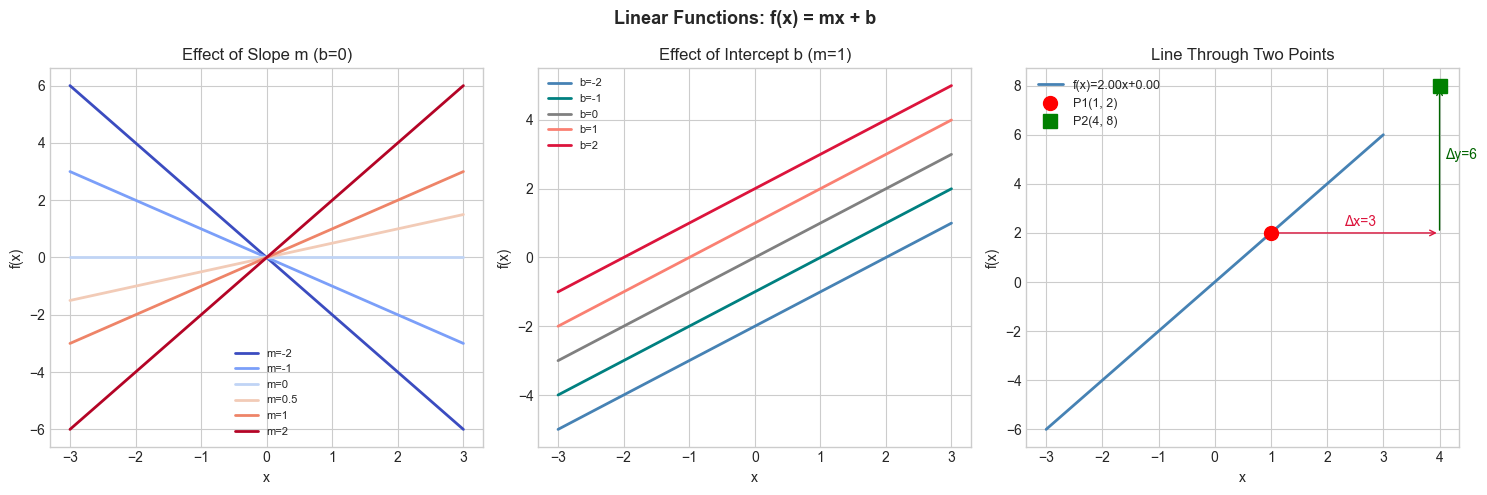

In [1]:
# --- Visualization: Linear functions and their parameters ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

x = np.linspace(-3, 3, 300)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Effect of slope
slopes = [-2, -1, 0, 0.5, 1, 2]
colors = plt.cm.coolwarm(np.linspace(0, 1, len(slopes)))
for m, color in zip(slopes, colors):
    axes[0].plot(x, m*x, color=color, linewidth=2, label=f'm={m}')
axes[0].set_title('Effect of Slope m (b=0)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend(fontsize=8)

# Panel 2: Effect of intercept
intercepts = [-2, -1, 0, 1, 2]
for b, color in zip(intercepts, ['steelblue','teal','gray','salmon','crimson']):
    axes[1].plot(x, x + b, color=color, linewidth=2, label=f'b={b}')
axes[1].set_title('Effect of Intercept b (m=1)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].legend(fontsize=8)

# Panel 3: Fitting a line through two points
p1, p2 = (1, 2), (4, 8)
m = (p2[1] - p1[1]) / (p2[0] - p1[0])
b = p1[1] - m * p1[0]
axes[2].plot(x, m*x + b, color='steelblue', linewidth=2, label=f'f(x)={m:.2f}x+{b:.2f}')
axes[2].plot(*p1, 'ro', markersize=10, zorder=5, label=f'P1{p1}')
axes[2].plot(*p2, 'gs', markersize=10, zorder=5, label=f'P2{p2}')
# Show slope triangle
axes[2].annotate('', xy=(p2[0], p1[1]), xytext=(p1[0], p1[1]),
                 arrowprops=dict(arrowstyle='->', color='crimson'))
axes[2].annotate('', xy=(p2[0], p2[1]), xytext=(p2[0], p1[1]),
                 arrowprops=dict(arrowstyle='->', color='darkgreen'))
axes[2].text(2.3, 2.3, f'Δx={p2[0]-p1[0]}', color='crimson', fontsize=10)
axes[2].text(4.1, 5, f'Δy={p2[1]-p1[1]}', color='darkgreen', fontsize=10)
axes[2].set_title('Line Through Two Points')
axes[2].set_xlabel('x')
axes[2].set_ylabel('f(x)')
axes[2].legend(fontsize=9)

plt.suptitle('Linear Functions: f(x) = mx + b', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

**Formula:** f(x) = mx + b
- m = slope = Δy / Δx = rate of change of f per unit change in x
- b = y-intercept = f(0)

**Line through two points (x₁, y₁) and (x₂, y₂):**
- m = (y₂ - y₁) / (x₂ - x₁)
- b = y₁ - m·x₁

**Linearity property (strict definition):**
- f(x + y) = f(x) + f(y) — only if b = 0
- f(cx) = c·f(x) — only if b = 0

f(x) = mx + b with b ≠ 0 is *affine*, not linear in the strict sense.

In [2]:
# --- Implementation: Linear function fitting ---
import numpy as np

def fit_line_two_points(p1, p2):
    """Compute slope and intercept through two points."""
    x1, y1 = p1
    x2, y2 = p2
    if x2 == x1:
        raise ValueError("Vertical line — not a function of x")
    m = (y2 - y1) / (x2 - x1)
    b = y1 - m * x1
    return m, b

def least_squares_line(x, y):
    """Fit y = mx + b by minimizing sum of squared residuals.
    Uses the closed-form normal equations: [m, b] = (XᵀX)⁻¹ Xᵀy
    (reappears in ch281 — Regression via Matrix Algebra)
    """
    n = len(x)
    # Build design matrix with ones column
    X = np.column_stack([x, np.ones(n)])
    # Normal equations
    XtX = X.T @ X
    Xty = X.T @ y
    coeffs = np.linalg.solve(XtX, Xty)
    return coeffs[0], coeffs[1]  # slope, intercept

# Generate noisy linear data
np.random.seed(0)
x_data = np.linspace(0, 10, 50)
y_data = 2.5 * x_data - 3.0 + np.random.normal(0, 2, 50)

m_fit, b_fit = least_squares_line(x_data, y_data)
print(f"Fitted: y = {m_fit:.3f}x + {b_fit:.3f}")
print(f"True:   y = 2.500x - 3.000")

Fitted: y = 2.218x + -1.307
True:   y = 2.500x - 3.000


---

## 5. Python Implementation

In [ ]:
# See Section 5. Extend: plot the fitted line with a shaded 95% confidence interval.
# Use: variance of residuals to estimate uncertainty in slope.

---

## 6. Experiments

**Experiment 1:** Generate y = 3x - 2 + noise(σ). Increase σ from 0.1 to 10. At what noise level does the fitted line become unreliable? (Measure by checking how far m and b drift from true values.)

**Experiment 2:** Test the linearity property: for f(x) = 2x, verify f(3+5) = f(3)+f(5). Then for g(x) = 2x+1, verify g(3+5) ≠ g(3)+g(5). This illustrates affine vs linear.

---

## 7. Exercises

**Easy 1.** Find slope and intercept of the line through (-2, 7) and (4, -5). *(Expected: m=-2, b=3)*

**Easy 2.** For f(x) = -3x + 4, what is f(0)? f(2)? Where does f(x) = 0? *(Expected: 4, -2, x=4/3)*

**Medium 1.** Generate 200 points from y = 1.8x + 32 (Celsius to Fahrenheit) with noise σ=3. Fit a line. How close do you get to the true m=1.8, b=32?

**Medium 2.** A function is linear iff f(αx+βy)=αf(x)+βf(y). Write a numerical test `is_linear(f, n_tests=100)` and verify: f(x)=3x passes, f(x)=3x+1 fails, f(x)=x² fails.

**Hard.** Derive the least-squares formulas for m and b from scratch by minimizing L(m,b) = Σᵢ (yᵢ - (mxᵢ+b))². Set ∂L/∂m=0 and ∂L/∂b=0 and solve the resulting system. Implement and verify against `least_squares_line`.

---

## 8. Mini Project

*(See Section 5 for full implementation. Extend by modifying parameters.)*

---

## 9. Chapter Summary & Connections

- f(x) = mx + b: slope controls rate of change, intercept shifts vertically
- Line through two points: m = Δy/Δx
- Least squares fitting minimizes sum of squared residuals
- Affine (b≠0) vs strictly linear (b=0) distinction matters in algebra

**Backward connection:** Extends ch041 (Exponential Growth) — linear growth is the slowest 'active' growth rate.

**Forward connections:**
- In ch152 (Matrix Multiplication), linear functions of vectors are represented as matrix-vector products
- Least-squares fitting reappears in ch281 (Regression) as the core of linear regression
- The slope concept becomes the *derivative* in ch205 — derivative of a linear function is its slope, everywhere